LAB 1 - STEP 1: LOAD THE CSV

In [ ]:
from google.colab import files
files.upload()



Saving supply_chain_disruption_risk.csv to supply_chain_disruption_risk (1).csv


{'supply_chain_disruption_risk (1).csv': b'country,year,logistics_score,trade_percent_gdp,gdp_usd_billion,inflation_percent,conflict_events,military_spending_usd_billion,disruption_risk\r\nIndia,2018,3.1,45.2,2710,3.9,12,66,1\r\nIndia,2019,3,44.8,2870,4.8,14,71,1\r\nIndia,2020,2.6,41,2660,6.6,18,73,1\r\nIndia,2021,3.2,46.5,3170,5.1,10,76,0\r\nIndia,2022,3.4,49,3390,6.7,9,81,0\r\nGermany,2018,4,87.5,3990,1.9,2,49,0\r\nGermany,2019,4.1,88.2,3860,1.4,1,50,0\r\nGermany,2020,3.5,83.1,3810,1.4,3,52,0\r\nGermany,2021,3.7,85,4250,3.1,4,56,1\r\nGermany,2022,3.6,86.2,4070,6.9,5,59,1\r\nChina,2018,3.6,38.5,13890,2.1,6,250,0\r\nChina,2019,3.6,37.8,14340,2.9,7,261,0\r\nChina,2020,3.4,34.5,14720,2.4,9,252,1\r\nChina,2021,3.5,36,17730,0.9,8,270,0\r\nChina,2022,3.3,35.2,17960,2,10,292,1\r\nUSA,2018,3.9,27.5,20580,2.4,3,649,0\r\nUSA,2019,3.9,26.9,21430,1.8,4,685,0\r\nUSA,2020,3.5,23,20940,1.2,6,778,1\r\nUSA,2021,3.7,24.8,23320,4.7,5,801,0\r\nUSA,2022,3.6,25.5,25460,8,7,877,1\r\nBrazil,2018,2.9,24.1,187

In [ ]:
import os

# List all files and directories in the current working directory and its subdirectories
for root, dirs, files in os.walk('/content/'):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

In [ ]:
import pandas as pd

df = pd.read_csv('/content/supply_chain_disruption_risk.csv')

STEP 2: LAB 1 — BASIC DATA CHECK

In [ ]:
print(df.shape)        # rows, columns
print(df.columns)      # column names
df.info()              # data types


(25, 9)
Index(['country', 'year', 'logistics_score', 'trade_percent_gdp',
       'gdp_usd_billion', 'inflation_percent', 'conflict_events',
       'military_spending_usd_billion', 'disruption_risk'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        25 non-null     object 
 1   year                           25 non-null     int64  
 2   logistics_score                25 non-null     float64
 3   trade_percent_gdp              25 non-null     float64
 4   gdp_usd_billion                25 non-null     int64  
 5   inflation_percent              25 non-null     float64
 6   conflict_events                25 non-null     int64  
 7   military_spending_usd_billion  25 non-null     int64  
 8   disruption_risk                25 non-null     int64  
dtypes: float64(

STEP 3: CHECK MISSING VALUES (LAB 1)

In [ ]:
df.isnull().sum()


,0
country,0
year,0
logistics_score,0
trade_percent_gdp,0
gdp_usd_billion,0
inflation_percent,0
conflict_events,0
military_spending_usd_billion,0
disruption_risk,0


STEP 4: ENCODE + SCALE (LAB 1 COMPLETION)  - Encode country (text → number)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])


Scale features


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['disruption_risk'])
y = df['disruption_risk']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



LAB 2 - Implementation of KNN and Naive Bayes Classifiers & Comparison of Metrics

STEP 1: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


STEP 2: KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("KNN Classification Report:\n", classification_report(y_test, knn_pred))


KNN Accuracy: 0.375
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       0.50      0.20      0.29         5

    accuracy                           0.38         8
   macro avg       0.42      0.43      0.37         8
weighted avg       0.44      0.38      0.35         8



STEP 3: Naive Bayes Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Naive Bayes Classification Report:\n", classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.5
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.67      0.50         3
           1       0.67      0.40      0.50         5

    accuracy                           0.50         8
   macro avg       0.53      0.53      0.50         8
weighted avg       0.57      0.50      0.50         8



STEP 4: Metric Comparison

In [ ]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))


KNN Accuracy: 0.375
Naive Bayes Accuracy: 0.5


LAB 3
Implementation of Tree-Based Classifier & K-Fold Cross Validation

STEP 1: Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy: 0.375


STEP 2: K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    dt,
    X_scaled,
    y,
    cv=kf,
    scoring='accuracy'
)

print("K-Fold Cross Validation Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())


K-Fold Cross Validation Scores: [0.8 0.8 0.4 0.4 0.6]
Average Accuracy: 0.6


LAB 4
Implementation of SVM and Comparison with Tree-Based Classifier

STEP 1: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)



STEP 2: Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))


SVM Accuracy: 0.375


STEP 3: Decision Tree (for Comparison)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy: 0.375


STEP 4: Comparison Output

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))


SVM Accuracy: 0.375
Decision Tree Accuracy: 0.375


lab 5 - Implementation of Ensemble Technique – Random Forest & Performance Analysis

STEP 1: Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


STEP 2: Random Forest Classifier (ENSEMBLE)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.375
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.67      0.44         3
           1       0.50      0.20      0.29         5

    accuracy                           0.38         8
   macro avg       0.42      0.43      0.37         8
weighted avg       0.44      0.38      0.35         8



STEP 3: Feature Importance

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance


,Feature,Importance
1,year,0.209462
2,logistics_score,0.151700
3,trade_percent_gdp,0.149524
7,military_spending_usd_billion,0.136108
6,conflict_events,0.126259
5,inflation_percent,0.094936
4,gdp_usd_billion,0.084666
0,country,0.047344


Optional visualization- graph

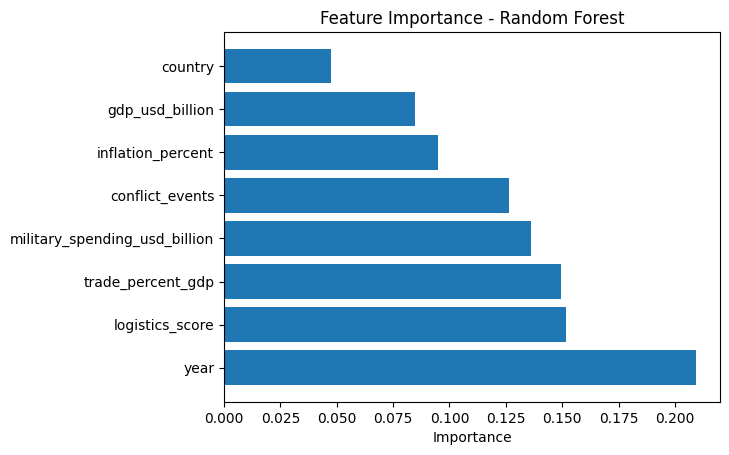

In [ ]:
import matplotlib.pyplot as plt

plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()


LAB 6
Implementation and Comparison of Clustering Techniques (DBSCAN & Spectral)

STEP 1: DBSCAN Clustering

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

dbscan = DBSCAN(eps=1.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Labels:", np.unique(dbscan_labels))


DBSCAN Cluster Labels: [-1  0  1  2]


Count points per cluster

In [ ]:
import pandas as pd

dbscan_cluster_counts = pd.Series(dbscan_labels).value_counts()
dbscan_cluster_counts


,count
-1,14
0,5
1,3
2,3


STEP 2: Spectral Clustering

In [ ]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=3,
    assign_labels='kmeans',
    random_state=42
)

spectral_labels = spectral.fit_predict(X_scaled)

print("Spectral Cluster Labels:", np.unique(spectral_labels))


Spectral Cluster Labels: [0 1 2]


Count clusters

In [ ]:
spectral_cluster_counts = pd.Series(spectral_labels).value_counts()
spectral_cluster_counts


,count
2,10
1,10
0,5


STEP 3: Comparison Output

In [ ]:
print("DBSCAN unique clusters:", np.unique(dbscan_labels))
print("Spectral unique clusters:", np.unique(spectral_labels))


DBSCAN unique clusters: [-1  0  1  2]
Spectral unique clusters: [0 1 2]


LAB 7
Implementation of Regression Technique & Performance Evaluation

STEP 1: Define Regression Features & Target

In [ ]:
# Target variable (continuous)
y = df['trade_percent_gdp']

# Features (remove target)
X = df.drop(columns=['trade_percent_gdp'])


STEP 2: Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


STEP 3: Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


STEP 4: Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)


STEP 5: Performance Evaluation

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Squared Error (MSE): 79.82326414516209
Root Mean Squared Error (RMSE): 8.93438661269827
R² Score: 0.8475855379346755


LAB 8 - MINI Project-  

Step A: Train Random Forest ONCE (best for risk)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Redefine X and y for classification (disruption_risk)
X = df.drop(columns=['disruption_risk'])
y = df['disruption_risk']

# Scale features again with the correct X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform train-test split again with the correct X_scaled and y
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)